<a href="https://colab.research.google.com/github/adarshabhattacharjee/UCI/blob/main/UCI_DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#SET UP AND LOADING DATA
---



In [1]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv
Saving IDS_mapping.csv to IDS_mapping.csv


In [2]:
!pip install -q shap lightgbm

In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)   # show all columns
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("diabetic_data.csv", na_values="?")
print(df.shape)                      # expect (101766, 50)
print(df["readmitted"].value_counts())
df.head()

(101766, 50)
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


#Going through the data

In [5]:
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted"].value_counts(normalize=True))
print(df["readmit_30"].mean())   # expect ~0.11

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64
0.11159915885462728


- not readmitted: 54 percent
- readmitted after 30 days: 35 percent
- readmitted within 30 days: 11

In [6]:
df["A1Cresult"] = df["A1Cresult"].fillna("NotTested")
df["max_glu_serum"] = df["max_glu_serum"].fillna("NotTested")

weight               0.968585
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
dtype: float64


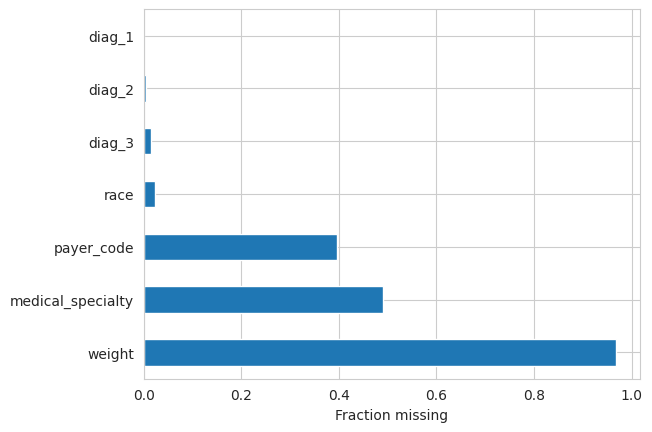

In [7]:
missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0])

missing[missing > 0].plot(kind="barh")
plt.xlabel("Fraction missing"); plt.show()

In [8]:
for col in ["medical_specialty", "payer_code", "race"]:
    print(df.groupby(df[col].isna())["readmit_30"].mean(), "\n")
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    print(df[col].value_counts().head(10), "\n")
print(df["gender"].value_counts())   # note the "Unknown/Invalid" rows

medical_specialty
False    0.107609
True     0.115738
Name: readmit_30, dtype: float64 

payer_code
False    0.109413
True     0.114939
Name: readmit_30, dtype: float64 

race
False    0.112259
True     0.082710
Name: readmit_30, dtype: float64 

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64 

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64 

admission_source_id
7     57494
1     29565
17     6781
4      3187
6      2264
2      1104
5       855
3       187
20      161
9       125
Name: count, dtype: int64 

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [9]:
# Duplicates and patient repetition
print("Unique patients:", df["patient_nbr"].nunique(), "of", len(df), "rows")
print(df["patient_nbr"].value_counts().head())

# Constant (zero-information) columns
const = [c for c in df.columns if df[c].nunique() <= 1]
print("Constant columns:", const)    # examide, citoglipton

# Impossible patients: expired/hospice cannot be readmitted
dead = [11, 13, 14, 19, 20, 21]
print("Expired/hospice rows:", df["discharge_disposition_id"].isin(dead).sum())
print(df[df["discharge_disposition_id"].isin(dead)]["readmit_30"].mean())  # ~0

Unique patients: 71518 of 101766 rows
patient_nbr
88785891    40
43140906    28
88227540    23
23199021    23
1660293     23
Name: count, dtype: int64
Constant columns: ['examide', 'citoglipton']
Expired/hospice rows: 2423
0.017746595130004126


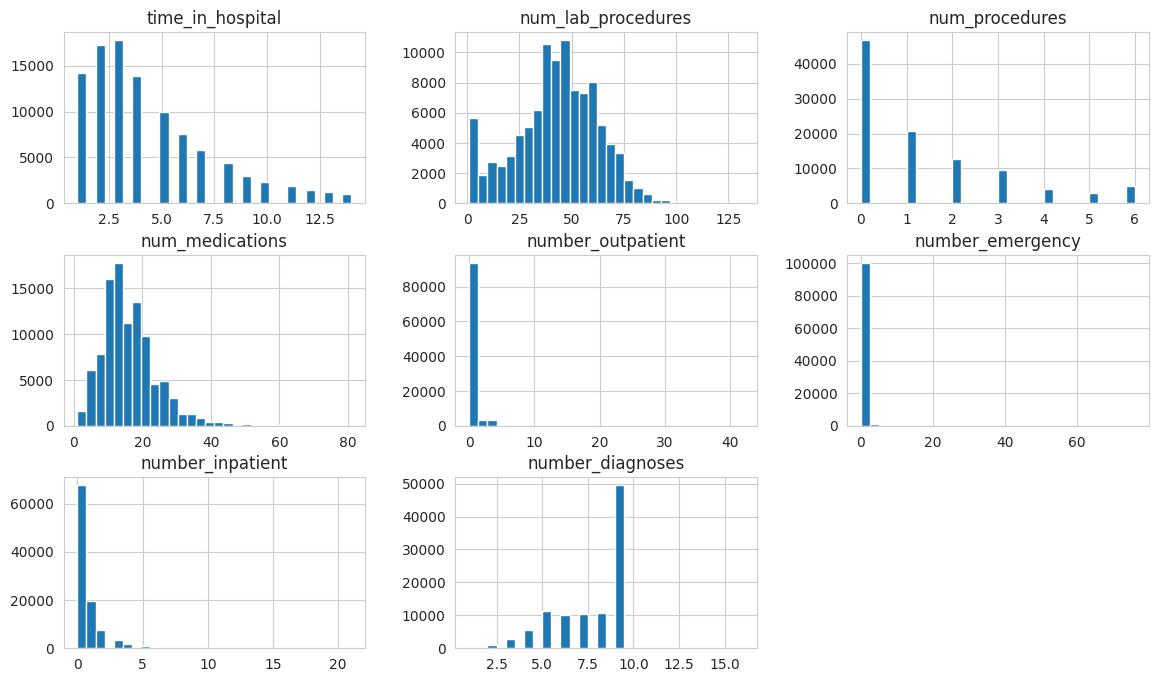

In [10]:
num_cols = ["time_in_hospital","num_lab_procedures","num_procedures",
            "num_medications","number_outpatient","number_emergency",
            "number_inpatient","number_diagnoses"]
df[num_cols].describe().T
df[num_cols].hist(bins=30, figsize=(14,8)); plt.show()

In [11]:
cat_cols = df.select_dtypes("object").columns
for c in cat_cols:
    print(c, df[c].nunique())

race 5
gender 3
age 10
weight 9
payer_code 17
medical_specialty 72
diag_1 716
diag_2 748
diag_3 789
max_glu_serum 4
A1Cresult 4
metformin 4
repaglinide 4
nateglinide 4
chlorpropamide 4
glimepiride 4
acetohexamide 2
glipizide 4
glyburide 4
tolbutamide 2
pioglitazone 4
rosiglitazone 4
acarbose 4
miglitol 4
troglitazone 2
tolazamide 3
examide 1
citoglipton 1
insulin 4
glyburide-metformin 4
glipizide-metformin 2
glimepiride-pioglitazone 2
metformin-rosiglitazone 2
metformin-pioglitazone 2
change 2
diabetesMed 2
readmitted 3


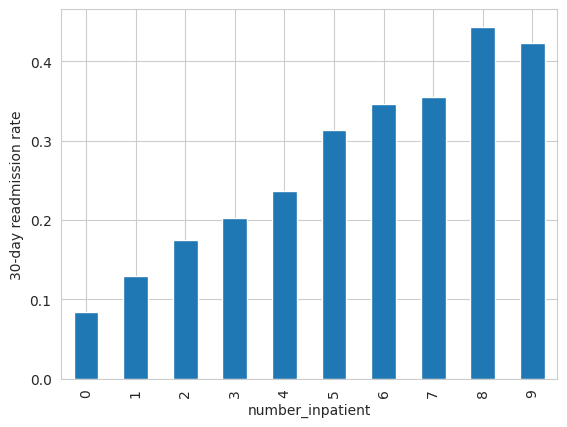

In [12]:
def rate_by(col, order=None):
    r = df.groupby(col)["readmit_30"].agg(["mean","count"])
    return r.loc[order] if order else r

# Prior inpatient visits (expect a strong upward trend)
rate_by("number_inpatient")

# Age
rate_by("age")

# Discharge disposition
rate_by("discharge_disposition_id").sort_values("mean", ascending=False)

# Visual
df.groupby("number_inpatient")["readmit_30"].mean().head(10).plot(kind="bar")
plt.ylabel("30-day readmission rate"); plt.show()

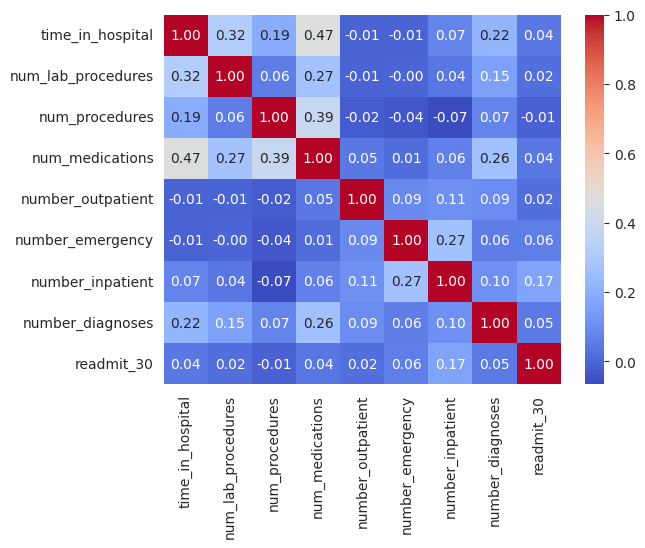

In [13]:
sns.heatmap(df[num_cols + ["readmit_30"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

#STEP 1: PREPROCESSING

In [14]:
df = pd.read_csv("diabetic_data.csv", na_values="?")
print("Start:", df.shape)            # (101766, 50)
data = df.copy()

Start: (101766, 50)


In [15]:
# Removing rows that should not be included
# 1) Expired (11,19,20,21) and hospice (13,14): these patients cannot be readmitted normally
exclude_codes = [11, 13, 14, 19, 20, 21]
n_before = len(data)
data = data[~data["discharge_disposition_id"].isin(exclude_codes)]
print("Removed expired/hospice:", n_before - len(data))     # 2423

# 2) Invalid gender
n_before = len(data)
data = data[data["gender"] != "Unknown/Invalid"]
print("Removed invalid gender:", n_before - len(data))      # 0-3 (some overlap with step 1 is possible)

print("Now:", data.shape)             # about (99,340, 50)

Removed expired/hospice: 2423
Removed invalid gender: 3
Now: (99340, 50)


In [16]:
# weight: 97% missing. examide/citoglipton: constant.
# encounter_id: just a row identifier. (Keep patient_nbr for now: needed for the grouped split.)
data = data.drop(columns=["weight", "examide", "citoglipton", "encounter_id"])

In [17]:
data["readmit_30"] = (data["readmitted"] == "<30").astype(int)
data = data.drop(columns=["readmitted"])      # remove the raw label so it cannot leak
print(data["readmit_30"].mean())              # about 0.113

0.1138916851218039


In [18]:
# "Not tested" is real information, not missing data
data["A1Cresult"] = data["A1Cresult"].fillna("NotTested")
data["max_glu_serum"] = data["max_glu_serum"].fillna("NotTested")

# Explicit Unknown category
for col in ["race", "payer_code", "medical_specialty"]:
    data[col] = data[col].fillna("Unknown")

# Keep top 10 medical specialties, group the rest
top_spec = data["medical_specialty"].value_counts().nlargest(10).index
data["medical_specialty"] = data["medical_specialty"].where(
    data["medical_specialty"].isin(top_spec), "Other")

# Merge the many "unknown" ID codes (check these against IDs_mapping.csv)
adm_type_unknown = [5, 6, 8]
disch_unknown    = [18, 25, 26]
adm_src_unknown  = [9, 15, 17, 20, 21]

data["admission_type_id"] = data["admission_type_id"].replace(adm_type_unknown, 0).replace([4, 7], 99)
data["discharge_disposition_id"] = data["discharge_disposition_id"].replace(disch_unknown, 0)
data["admission_source_id"] = data["admission_source_id"].replace(adm_src_unknown, 0)

# These are categories, not quantities, so store them as strings
for c in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    data[c] = data[c].astype(str)

In [19]:
def group_icd9(code):
    if pd.isna(code):
        return "Unknown"
    code = str(code)
    if code.startswith(("V", "E")):
        return "Other"
    num = float(code)
    if 250 <= num < 251:               return "Diabetes"
    if 390 <= num <= 459 or num == 785: return "Circulatory"
    if 460 <= num <= 519 or num == 786: return "Respiratory"
    if 520 <= num <= 579 or num == 787: return "Digestive"
    if 580 <= num <= 629 or num == 788: return "Genitourinary"
    if 800 <= num <= 999:               return "Injury"
    if 710 <= num <= 739:               return "Musculoskeletal"
    if 140 <= num <= 239:               return "Neoplasms"
    return "Other"

for c in ["diag_1", "diag_2", "diag_3"]:
    data[c] = data[c].apply(group_icd9)

print(data["diag_1"].value_counts())

diag_1
Circulatory        29680
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6851
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Unknown               20
Name: count, dtype: int64


In [20]:
age_map = {"[0-10)":5, "[10-20)":15, "[20-30)":25, "[30-40)":35, "[40-50)":45,
           "[50-60)":55, "[60-70)":65, "[70-80)":75, "[80-90)":85, "[90-100)":95}

if data["age"].dtype == "object":
    data["age"] = data["age"].map(age_map)

assert data["age"].notna().all(), "Some age brackets did not match the map"

In [22]:
print("Missing values left:", data.isna().sum().sum())      # should be 0
print("Shape:", data.shape)
print(data.dtypes.value_counts())
data.head()

Missing values left: 0
Shape: (99340, 46)
object    35
int64     11
Name: count, dtype: int64


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmit_30
0,8222157,Caucasian,Female,5,0,0,1,1,Unknown,Other,41,0,1,0,0,0,Diabetes,Unknown,Unknown,1,NotTested,NotTested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,55629189,Caucasian,Female,15,1,1,7,3,Unknown,Unknown,59,0,18,0,0,0,Other,Diabetes,Other,9,NotTested,NotTested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
2,86047875,AfricanAmerican,Female,25,1,1,7,2,Unknown,Unknown,11,5,13,2,0,1,Other,Diabetes,Other,6,NotTested,NotTested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,82442376,Caucasian,Male,35,1,1,7,2,Unknown,Unknown,44,1,16,0,0,0,Other,Diabetes,Circulatory,7,NotTested,NotTested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,42519267,Caucasian,Male,45,1,1,7,1,Unknown,Unknown,51,0,8,0,0,0,Neoplasms,Neoplasms,Diabetes,5,NotTested,NotTested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


In [21]:
from sklearn.model_selection import GroupShuffleSplit

groups = data["patient_nbr"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(data, data["readmit_30"], groups))

train = data.iloc[train_idx].copy()
test  = data.iloc[test_idx].copy()

# Proof that no patient is on both sides
overlap = set(train["patient_nbr"]) & set(test["patient_nbr"])
print("Patients in both sets:", len(overlap))               # must be 0
print("Train rows:", len(train), "| Test rows:", len(test))
print("Positive rate train / test:", train["readmit_30"].mean().round(4), test["readmit_30"].mean().round(4))

Patients in both sets: 0
Train rows: 79567 | Test rows: 19773
Positive rate train / test: 0.114 0.1135


In [23]:
X_train = train.drop(columns=["readmit_30", "patient_nbr"])
y_train = train["readmit_30"]
g_train = train["patient_nbr"]          # kept for grouped cross-validation later
X_test  = test.drop(columns=["readmit_30", "patient_nbr"])
y_test  = test["readmit_30"]

train.to_csv("train_clean.csv", index=False)
test.to_csv("test_clean.csv", index=False)

##README for preprocessing
---------
1. Working with the "?"

If it stays panda treats it as a real value which makes the missing record to be zero as it has some value. Therefore, it needs to be removed.

2. Removal of expired/hospice patients and invalid gender rows

- dead/hospice people are removed cause they cannot be readmitted.
Therefore prediction wont be used on them
- Invalid gender (3 rows): The model cannot learn anything reliable from such little information. thereby removing them will make the dataset cleaner.

3. Dropping weight, examide, citoglipton, encounter id
- Weight is recorded only fro 3 percent of the population
- No patient was ever given the drug examide or citoglipton
- Every patient has a unique id which is not going to help predict anything

4. Defining the target

The target is readmission before 30 days, We give the same value to the readmitted and the people who do not come back as we cannot predict beyond 30 days.

5. Removal of ambiguous parts
- "NotTested" for A1Cresult and max_glu_serum (It does not tell how the patient was managed.)
- "Unknown" for race, payer_code, medical_specialty
- Keeping only the top 10 medical speciality as there are 72 and top 10 cover most of them, and grouping the rest as others.(includes unknown which is around 49 percent)
It prevents some problems like overfitting.
- Merging the "NULL / Not Available / Not Mapped" ID codes
- Converting ID columns to strings since they are labels and not quantities

6. Group ICD-9(correspond to body systems) diagnosis codes into about 9 categories
- Mapped 716-789 unique codes per column into Circulatory, Respiratory, Digestive, Diabetes, Genitourinary, Injury, Musculoskeletal, Neoplasms, Other, and Unknown.
- Grouping uses clinical knowledge , so related conditions share statistical strength. This is the same grouping used in the original study by Strack et al. (2014), so your results are comparable to the literature.
7. Converting the age brackets into the midpoint of the age bracket (in the interval of 10)
8. It groups the patients who came more than one time and then assign the patients to train(80.1 percent) ot test(19.9 percent)

    WHY?
    - If the same person goes several times the model learns the pattern of that person. If an unknown person is to be tested upon it would thereby lead to a worse accuracy.
    - Grouping and later spliting proves that every patient is a stranger to the model.





In [24]:
#checking is all the preprocessing is done right
assert X_train.isna().sum().sum() == 0, "Missing values remain"

forbidden = {"readmit_30", "readmitted", "patient_nbr", "encounter_id"}
leaks = forbidden & set(X_train.columns)
assert not leaks, f"Leaky or ID columns present: {leaks}"

print(X_train.shape, X_test.shape)
print(y_train.mean().round(4), y_test.mean().round(4))

cat_cols = X_train.select_dtypes("object").columns.tolist()
num_cols = X_train.select_dtypes("number").columns.tolist()
print(len(cat_cols), "categorical |", len(num_cols), "numeric")
print(X_train[["admission_type_id","discharge_disposition_id","admission_source_id"]].dtypes)

(79567, 44) (19773, 44)
0.114 0.1135
35 categorical | 9 numeric
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
dtype: object


In [25]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "average_precision"]

def run_cv(model, X, name):
    res = cross_validate(model, X, y_train, groups=g_train, cv=cv,
                         scoring=scoring, n_jobs=-1)
    print(f"{name:28s} AUROC {res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}"
          f" | AUPRC {res['test_average_precision'].mean():.3f} ± {res['test_average_precision'].std():.3f}")

run_cv(DummyClassifier(strategy="prior"), X_train, "Dummy (no skill)")

Dummy (no skill)             AUROC 0.500 ± 0.000 | AUPRC 0.114 ± 0.003


In the dummy model, it has ignores every feature and gives every patient the same score thereby learning nothing about the individual patient.

AUROC - It gives both the readmitted and the non-readmitted patient the same same risk score. This makes it 1/2.
This is therefore treated as the baseline model.

In [26]:
def make_preprocessor(cat_cols, num_cols, scale=True):
    num = StandardScaler() if scale else "passthrough"
    return ColumnTransformer([
        ("num", num, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                              min_frequency=20), cat_cols),
    ])

logreg = Pipeline([
    ("prep", make_preprocessor(cat_cols, num_cols, scale=True)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, C=0.1)),
])
run_cv(logreg, X_train, "Logistic regression")

Logistic regression          AUROC 0.662 ± 0.008 | AUPRC 0.211 ± 0.012


Changes made from the dummy model to the regression one
1. One-hot encoding
- give the same value to each column for a particular category(1-yes, 0-no)
2. Balancing class weight

About 11.4 percent of the patients were readmitted. Thereby, the rare positive, here readmitting patients, is given more weight as the if equal weights are given then it will be predicting not readmitted for most of the cases and gets a good accuracy of 88.6 but that overshadows the purpose of the model.

3. Regularization

Problem- overfitting as it might learn from patterns which might be just pure noise and give equal importance to the one where the pattern is evident and is not present just cause of fluke.
The regularization shrinks the feature weight to zero and the if the feature is strongly evident in the dataset, it is given a much more larger weight.

4. C=0.1(Inverse Regularization Strength)

It is selected as a reasonable default.




In [27]:
gb = Pipeline([
    ("prep", make_preprocessor(cat_cols, num_cols, scale=False)),   # trees don't need scaling
    ("clf", HistGradientBoostingClassifier(
        learning_rate=0.05, # each new tree corrects only 5% of remaining error
        max_iter=300, # maximum number of trees
        max_depth=4, # shallow trees -> only low-order interactions, less overfitting
        min_samples_leaf=50, l2_regularization=1.0,
        class_weight="balanced",
        early_stopping=True, # stop adding trees when a held-out slice stops improving
        validation_fraction=0.1, # 10% of the training data is used for that check
        random_state=42)),
])
run_cv(gb, X_train, "Gradient boosting")

Gradient boosting            AUROC 0.671 ± 0.007 | AUPRC 0.225 ± 0.011


Gradient boosting
1. Learning rate is 0.05 as shrinking the updates would prevent it from overfitting from early noise
2. Shallow trees allows them learn from low ordered features rather than non repeating complex patterns.
3. The minimum samples leaf prevents it from learning from individual rather finds similarity between 50 individuals to learn.
4. Early stopping prevents overfitting.


In [28]:
med_cols = ["metformin","repaglinide","nateglinide","chlorpropamide","glimepiride",
            "acetohexamide","glipizide","glyburide","tolbutamide","pioglitazone",
            "rosiglitazone","acarbose","miglitol","troglitazone","tolazamide","insulin",
            "glyburide-metformin","glipizide-metformin","glimepiride-pioglitazone",
            "metformin-rosiglitazone","metformin-pioglitazone"]

def add_features(X):
    X = X.copy()
    X["total_prior_visits"] = X["number_outpatient"] + X["number_emergency"] + X["number_inpatient"]
    X["n_meds_taken"]   = (X[med_cols] != "No").sum(axis=1)
    X["n_meds_changed"] = X[med_cols].isin(["Up", "Down"]).sum(axis=1)
    X["n_diag_groups"]  = X[["diag_1","diag_2","diag_3"]].nunique(axis=1)
    return X

X_train_fe = add_features(X_train)
num_cols_fe = X_train_fe.select_dtypes("number").columns.tolist()

logreg_fe = Pipeline([("prep", make_preprocessor(cat_cols, num_cols_fe, True)),
                      ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, C=0.1))])
gb_fe = Pipeline([("prep", make_preprocessor(cat_cols, num_cols_fe, False)),
                  ("clf", gb.named_steps["clf"])])

run_cv(logreg_fe, X_train_fe, "LogReg + engineered")
run_cv(gb_fe,     X_train_fe, "Boosting + engineered")

LogReg + engineered          AUROC 0.662 ± 0.007 | AUPRC 0.211 ± 0.012
Boosting + engineered        AUROC 0.670 ± 0.007 | AUPRC 0.225 ± 0.011


##Added Feature engineering

- total prior visits
- Counts people taking multiple drugs as they tend to be severly diabetic.
- see's how many times the meds were changed to measure the instability
- measures people with more than one diagonastic method as they are clinically more complex.



In [29]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
import numpy as np

oof = cross_val_predict(clone(gb), X_train, y_train, groups=g_train, cv=cv,
                        method="predict_proba", n_jobs=-1)[:, 1]
print("OOF mean raw score:", oof.mean().round(3), "| true rate:", y_train.mean().round(3))

OOF mean raw score: 0.461 | true rate: 0.114


The mismatch between 0.114 and 0.461 exists due to the the extra weightage given to the readmitted rate in the beggining.

In [30]:
from sklearn.isotonic import IsotonicRegression

# Capacity-based rule: flag the top 10% highest-risk patients
thr = np.quantile(oof, 0.90)

# Calibrator: maps raw scores to real probabilities
iso = IsotonicRegression(out_of_bounds="clip").fit(oof, y_train)
print("Threshold (raw score):", thr.round(3))

Threshold (raw score): 0.636


It increased the threshold to top 90, therefore flagging the top 10 highest at risk patients.
Isotonic regression - It lowers and corrects the score value ( the mean score of 0.461)

In [31]:
final = clone(gb).fit(X_train, y_train)
p_raw = final.predict_proba(X_test)[:, 1]
p_cal = iso.predict(p_raw)
yt = y_test.values

In [32]:
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             brier_score_loss, precision_score, recall_score)

print("AUROC:", round(roc_auc_score(yt, p_raw), 3))
print("AUPRC:", round(average_precision_score(yt, p_raw), 3), "| no-skill:", round(yt.mean(), 3))

flag = p_raw >= thr
prec = precision_score(yt, flag)
rec  = recall_score(yt, flag)
print(f"\nFlagged: {flag.mean():.1%} of patients")
print("Precision (readmit rate among flagged):", round(prec, 3))
print("Recall (share of all readmissions caught):", round(rec, 3))
print("Lift vs average:", round(prec / yt.mean(), 2), "x")
print("\nConfusion matrix [[TN FP],[FN TP]]:\n", confusion_matrix(yt, flag))

for q in [0.05, 0.10, 0.20, 0.30]:
    t = np.quantile(oof, 1 - q); f = p_raw >= t
    print(f"Top {q:.0%}: flagged {f.mean():.1%} | recall {recall_score(yt,f):.2f} | "
          f"precision {precision_score(yt,f):.2f}")

AUROC: 0.679
AUPRC: 0.24 | no-skill: 0.113

Flagged: 10.6% of patients
Precision (readmit rate among flagged): 0.28
Recall (share of all readmissions caught): 0.261
Lift vs average: 2.47 x

Confusion matrix [[TN FP],[FN TP]]:
 [[16025  1504]
 [ 1659   585]]
Top 5%: flagged 5.7% | recall 0.16 | precision 0.32
Top 10%: flagged 10.6% | recall 0.26 | precision 0.28
Top 20%: flagged 20.2% | recall 0.40 | precision 0.23
Top 30%: flagged 29.4% | recall 0.52 | precision 0.20


##Readings
- Flagged : 10.6

It means the model alerted these many percent patients
- Precision : 0.28

It means how many of the flagged patients were truly readmitted
- Recall : 0.261

It mean out of the many patients that were actually readmitted, how many were predicted to be readmitted.
- Lift : 2.47 x

Pricision/readmitted rate : It means flagged patients have 2.47 x chances to get readmitted.


Repeated several times with top 5, 10, 20, 30

Brier raw: 0.2193
Brier calibrated: 0.0952
Brier of 'always predict the average': 0.1006


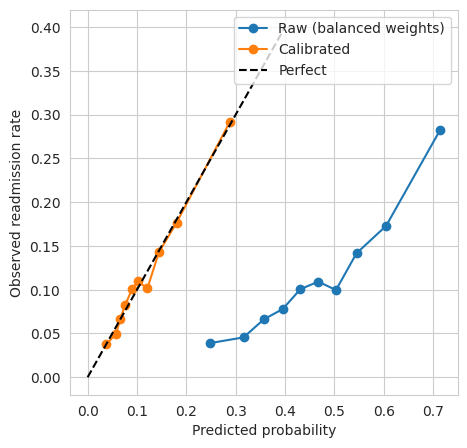

In [33]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

base = yt.mean() * (1 - yt.mean())
print("Brier raw:", brier_score_loss(yt, p_raw).round(4))
print("Brier calibrated:", brier_score_loss(yt, p_cal).round(4))
print("Brier of 'always predict the average':", base.round(4))

plt.figure(figsize=(5,5))
for p, lab in [(p_raw, "Raw (balanced weights)"), (p_cal, "Calibrated")]:
    frac, mean_p = calibration_curve(yt, p, n_bins=10, strategy="quantile")
    plt.plot(mean_p, frac, marker="o", label=lab)
plt.plot([0, 0.4], [0, 0.4], "k--", label="Perfect")
plt.xlabel("Predicted probability"); plt.ylabel("Observed readmission rate")
plt.legend(); plt.show()

In [34]:
g_test = test["patient_nbr"].values
idx_groups = list(pd.Series(np.arange(len(g_test))).groupby(g_test).indices.values())
rng = np.random.default_rng(42)
aucs = []
for _ in range(200):
    sel = rng.integers(0, len(idx_groups), len(idx_groups))
    idx = np.concatenate([idx_groups[i] for i in sel])
    aucs.append(roc_auc_score(yt[idx], p_raw[idx]))
print("AUROC 95% CI:", np.percentile(aucs, [2.5, 97.5]).round(3))

AUROC 95% CI: [0.665 0.691]


We bootstraped as resampling by patient matters because one patient can have several encounters. Resampling rows would treat them as independent and give an interval that is too narrow.

In [38]:
from sklearn.inspection import permutation_importance

r = permutation_importance(final, X_test, yt, scoring="roc_auc",
                           n_repeats=5, random_state=42, n_jobs=-1)
imp = (pd.DataFrame({"feature": X_test.columns,
                     "auroc_drop": r.importances_mean,
                     "std": r.importances_std})
         .sort_values("auroc_drop", ascending=False))
print(imp.head(15).to_string(index=False))

top = imp.head(12).iloc[::-1]
plt.figure(figsize=(7,5))
plt.barh(top["feature"], top["auroc_drop"], xerr=top["std"])
plt.xlabel("Drop in AUROC when shuffled"); plt.tight_layout(); plt.show()

KeyboardInterrupt: 

Permutation importance evaluates feature reliance by shuffling the values of a single column in the test set, recalculating the AUROC score, and measuring the performance drop across 5 iterations.

In this we that:

- 1) Number_inpatient alone accounts for a drop of ~0.077 AUROC (taking baseline performance from ~0.68 down to ~0.60).

  2) discharge_disposition_id causes a drop of ~0.050 AUROC (dropping it down to ~0.63).
  
  Together, these two features account for almost all of the model's discriminative ability.

- For the features at the bottom, their contribution is statistically indistinguishable from random noise.

In [36]:
for col in ["number_inpatient", "discharge_disposition_id", "number_emergency"]:
    t = train.groupby(col)["readmit_30"].agg(["mean", "count"])
    print(t[t["count"] >= 200].round(3), "\n")

                   mean  count
number_inpatient              
0                 0.086  52952
1                 0.133  15228
2                 0.180   5867
3                 0.205   2658
4                 0.235   1248
5                 0.330    646
6                 0.366    388
7                 0.353    224 

                           mean  count
discharge_disposition_id              
0                         0.118   3731
1                         0.093  48254
2                         0.163   1699
22                        0.277   1598
23                        0.072    320
3                         0.149  11139
4                         0.127    648
5                         0.200    934
6                         0.124  10419
7                         0.152    488 

                   mean  count
number_emergency              
0                 0.107  70644
1                 0.149   6019
2                 0.183   1591
3                 0.210    585
4                 0.320    284 


Readmission
- It shows that the more times a patient has been admitted to the hospital in the past, the more likely they are to be readmitted again—and this risk increases smoothly and predictably with every single additional stay.

Discharge Destination
- Where a patient is discharged heavily reflects their underlying complexity and illness severity.
- The number correlates to the destination of the patient after the discharge.

Prior Emergency visits
- While the risk jumps to 32 percent at 4 visits, the sample size is small (n = 284), making this estimate noisy with a margin of error around 5 percent.


In [37]:
dec = pd.qcut(p_raw, 10, labels=False, duplicates="drop")
tab = (pd.DataFrame({"decile": dec, "y": yt, "p_cal": p_cal})
         .groupby("decile").agg(n=("y", "size"),
                                observed=("y", "mean"),
                                predicted=("p_cal", "mean")))
print(tab.round(3))

           n  observed  predicted
decile                           
0       1978     0.039      0.038
1       1977     0.046      0.056
2       1977     0.066      0.065
3       1977     0.078      0.074
4       1978     0.101      0.089
5       1977     0.109      0.101
6       1977     0.100      0.119
7       1977     0.142      0.142
8       1977     0.173      0.177
9       1978     0.282      0.280


The overall average across both observed and predicted columns is almost 11.4 percent, matching the overall population baseline readmission rate.
